# Normalizado vs. Denormalizado: PostgreSQL vs MongoDB
### Caso: perfil de usuario en un portal de empleo

**Objetivo de esta práctica:** comparar, con datos reales y tiempos medidos (no solo en
teoría), el costo de leer una estructura jerárquica (1 usuario &rarr; N experiencias
laborales &rarr; N títulos) cuando está modelada de forma **normalizada (3FN, en
PostgreSQL)** contra el mismo caso modelado de forma **denormalizada (documentos
embebidos, en MongoDB)**.

Este notebook instala **PostgreSQL y MongoDB en la propia máquina de Colab**, genera un
dataset sintético que se carga en ambos motores **con exactamente
los mismos datos**, y corre varias consultas cronometradas.



## Parte 0 — Setup del entorno

Instalamos PostgreSQL (paquete oficial de Ubuntu) y MongoDB (repositorio oficial de
Mongo) directamente en la VM de Colab. Ninguno de los dos corre como servicio de
sistema (no hay `systemd` en Colab), así que los arrancamos "a mano".


In [ ]:
%%bash
# --- PostgreSQL ---
export DEBIAN_FRONTEND=noninteractive
apt-get -qq update
apt-get -qq install -y postgresql postgresql-contrib > /dev/null
service postgresql start
sleep 2
service postgresql status


 * Starting PostgreSQL 14 database server
   ...done.
14/main (port 5432): online


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# Creamos un usuario/rol con password conocido y la base de datos que vamos a usar
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"
!sudo -u postgres psql -c "DROP DATABASE IF EXISTS portal_empleo;"
!sudo -u postgres psql -c "CREATE DATABASE portal_empleo;"


ALTER ROLE
NOTICE:  database "portal_empleo" does not exist, skipping
DROP DATABASE
CREATE DATABASE


In [ ]:
%%bash
# --- MongoDB ---
# Este paso prueba varias combinaciones de version de Mongo / codename de Ubuntu,
# porque la imagen de Ubuntu que usa Colab cambia con el tiempo y el repo oficial
# de Mongo tarda en sumar soporte para los codenames mas nuevos. Si TODAS las
# combinaciones fallan, mirar el log completo de esta celda: ahi va a aparecer el
# error real (404 de apt, fallo de curl, etc.) para agregar una combinacion mas.
set -uo pipefail
CODENAME=$(lsb_release -cs)
echo "Ubuntu codename detectado: $CODENAME"

install_mongo () {
    local ver="$1" cn="$2"
    echo ">>> Intentando mongodb-org $ver para codename '$cn'..."
    rm -f /etc/apt/sources.list.d/mongodb-org-*.list
    rm -f /usr/share/keyrings/mongodb-server-*.gpg
    curl -fsSL "https://pgp.mongodb.com/server-${ver}.asc" | gpg -o "/usr/share/keyrings/mongodb-server-${ver}.gpg" --dearmor || return 1
    echo "deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-${ver}.gpg ] https://repo.mongodb.org/apt/ubuntu ${cn}/mongodb-org/${ver} multiverse" \
        | tee "/etc/apt/sources.list.d/mongodb-org-${ver}.list" > /dev/null
    apt-get -qq update || return 1
    apt-get -qq install -y mongodb-org || return 1
    return 0
}

OK=0
# Probamos primero el codename real detectado (con Mongo 8.0 y 7.0), y si Mongo
# todavia no lo soporta, caemos a codenames mas viejos que siempre estan
# soportados: los paquetes de Ubuntu son compatibles hacia adelante para esto.
for combo in "8.0 $CODENAME" "7.0 $CODENAME" "8.0 jammy" "7.0 jammy" "7.0 focal"; do
    set -- $combo
    if install_mongo "$1" "$2"; then
        echo ">>> OK con mongodb-org $1 / $2"
        OK=1
        break
    else
        echo ">>> Fallo con mongodb-org $1 / $2, probando siguiente opcion..."
    fi
done

if [ "$OK" -ne 1 ]; then
    echo "!!! No se pudo instalar mongodb-org con ninguna combinacion. Revisar el output de arriba."
    exit 1
fi

if ! command -v mongod >/dev/null 2>&1; then
    echo "!!! mongod no quedo instalado (el binario no esta en el PATH)."
    exit 1
fi

# dbpath e logpath propios, con permisos explicitos para el usuario "mongodb"
# (el punto que mas rompe esta receta: si el logpath queda en un directorio que
# no le pertenece a "mongodb", el --fork falla en silencio).
mkdir -p /data/db /var/log/mongodb
chown -R mongodb:mongodb /data/db /var/log/mongodb

sudo -u mongodb mongod --fork --logpath /var/log/mongodb/mongod.log --dbpath /data/db --bind_ip 127.0.0.1
sleep 3
echo "--- ultimas lineas del log de mongod ---"
tail -n 15 /var/log/mongodb/mongod.log


Ubuntu codename detectado: jammy
>>> Intentando mongodb-org 8.0 para codename 'jammy'...
Selecting previously unselected package mongodb-database-tools.
(Reading database ... 120390 files and directories currently installed.)
Preparing to unpack .../0-mongodb-database-tools_100.18.0_amd64.deb ...
Unpacking mongodb-database-tools (100.18.0) ...
Selecting previously unselected package mongodb-mongosh.
Preparing to unpack .../1-mongodb-mongosh_2.10.0_amd64.deb ...
Unpacking mongodb-mongosh (2.10.0) ...
Selecting previously unselected package mongodb-org-shell.
Preparing to unpack .../2-mongodb-org-shell_8.0.30_amd64.deb ...
Unpacking mongodb-org-shell (8.0.30) ...
Selecting previously unselected package mongodb-org-server.
Preparing to unpack .../3-mongodb-org-server_8.0.30_amd64.deb ...
Unpacking mongodb-org-server (8.0.30) ...
Selecting previously unselected package mongodb-org-mongos.
Preparing to unpack .../4-mongodb-org-mongos_8.0.30_amd64.deb ...
Unpacking mongodb-org-mongos (8.0.30

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# Librerias de Python que vamos a usar
!pip install -q faker psycopg2-binary pymongo pandas matplotlib

import time, random, io, statistics
import psycopg2
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker

# Chequeo rapido de que ambos motores responden
pg_test = psycopg2.connect(dbname="postgres", user="postgres", password="postgres", host="localhost")
print("PostgreSQL OK:", pg_test.closed == 0)
pg_test.close()

mongo_test = pymongo.MongoClient("mongodb://localhost:27017", serverSelectionTimeoutMS=5000)
print("MongoDB OK:", mongo_test.admin.command("ping"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 18.6 MB/s eta 0:00:00
PostgreSQL OK: True
MongoDB OK: {'ok': 1.0}


## Parte 1 — El modelo relacional (normalizado, 3FN)

```
Usuarios   (id_usuario PK, nombre, apellido, bio)
Experiencia(id_exp PK, id_usuario FK, empresa, cargo, anio_inicio, anio_fin)
Educacion  (id_edu PK, id_usuario FK, institucion, titulo)
```

Un usuario tiene **muchas** experiencias y **muchos** títulos: dos relaciones 1:N
clásicas, resueltas -como corresponde en 3FN- con tablas separadas y claves foráneas.


In [ ]:
conn = psycopg2.connect(dbname="portal_empleo", user="postgres", password="postgres", host="localhost")
conn.autocommit = True
cur = conn.cursor()

cur.execute('''
CREATE TABLE usuarios (
    id_usuario  SERIAL PRIMARY KEY,
    nombre      TEXT NOT NULL,
    apellido    TEXT NOT NULL,
    bio         TEXT
);
CREATE TABLE experiencia (
    id_exp       SERIAL PRIMARY KEY,
    id_usuario   INT REFERENCES usuarios(id_usuario),
    empresa      TEXT,
    cargo        TEXT,
    anio_inicio  INT,
    anio_fin     INT
);
CREATE TABLE educacion (
    id_edu       SERIAL PRIMARY KEY,
    id_usuario   INT REFERENCES usuarios(id_usuario),
    institucion  TEXT,
    titulo       TEXT
);
''')
print("Esquema normalizado creado.")


Esquema normalizado creado.


### Generación de datos sintéticos

Generamos los datos **una sola vez, en memoria**, y los usamos para poblar tanto
Postgres como Mongo. Así garantizamos que ambos motores tienen exactamente la misma
información y la comparación es justa.

`N_USERS` es el único parámetro que hace falta tocar para escalar el experimento
(subite a 100.000 si querés diferencias más dramáticas fuera de clase; con el valor
default alcanza para ver el fenómeno sin que la carga tarde varios minutos).


In [ ]:
random.seed(42)
Faker.seed(42)
fake = Faker("es_AR")

N_USERS = 25000          # cantidad de perfiles a simular
MIN_EXP, MAX_EXP = 1, 5  # experiencias laborales por usuario
MIN_EDU, MAX_EDU = 1, 3  # titulos por usuario

t0 = time.time()
usuarios = []       # (id, nombre, apellido, bio)
experiencias = []   # (id_usuario, empresa, cargo, anio_inicio, anio_fin)
educaciones = []    # (id_usuario, institucion, titulo)
docs_mongo = []     # documentos embebidos listos para insertar en Mongo

for uid in range(1, N_USERS + 1):
    nombre, apellido = fake.first_name(), fake.last_name()
    bio = fake.text(max_nb_chars=180)
    usuarios.append((uid, nombre, apellido, bio))

    exps = []
    for _ in range(random.randint(MIN_EXP, MAX_EXP)):
        empresa, cargo = fake.company(), fake.job()
        anio_inicio = random.randint(2005, 2023)
        anio_fin = anio_inicio + random.randint(1, 5)
        experiencias.append((uid, empresa, cargo, anio_inicio, anio_fin))
        exps.append({"empresa": empresa, "cargo": cargo, "anio_inicio": anio_inicio, "anio_fin": anio_fin})

    edus = []
    for _ in range(random.randint(MIN_EDU, MAX_EDU)):
        institucion = fake.company() + " University"
        titulo = random.choice(["Licenciatura", "Ingenieria", "Tecnicatura", "Maestria"])
        educaciones.append((uid, institucion, titulo))
        edus.append({"institucion": institucion, "titulo": titulo})

    docs_mongo.append({
        "_id": uid, "nombre": nombre, "apellido": apellido, "bio": bio,
        "experiencia": exps, "educacion": edus,
    })

print(f"Generados {N_USERS} usuarios, {len(experiencias)} experiencias, {len(educaciones)} titulos "
      f"en {time.time()-t0:.2f}s")


Generados 25000 usuarios, 74816 experiencias, 50032 titulos en 11.18s


In [ ]:
# Carga masiva en Postgres via COPY (mucho mas rapido que INSERT fila por fila)
def to_tsv(rows):
    buf = io.StringIO()
    for row in rows:
        buf.write("\t".join(str(v).replace("\t", " ").replace("\n", " ") for v in row) + "\n")
    buf.seek(0)
    return buf

t0 = time.time()
cur.copy_expert("COPY usuarios (id_usuario,nombre,apellido,bio) FROM STDIN WITH (FORMAT text)", to_tsv(usuarios))
cur.copy_expert("COPY experiencia (id_usuario,empresa,cargo,anio_inicio,anio_fin) FROM STDIN WITH (FORMAT text)", to_tsv(experiencias))
cur.copy_expert("COPY educacion (id_usuario,institucion,titulo) FROM STDIN WITH (FORMAT text)", to_tsv(educaciones))
cur.execute("CREATE INDEX idx_exp_user ON experiencia(id_usuario);")
cur.execute("CREATE INDEX idx_edu_user ON educacion(id_usuario);")
cur.execute("ANALYZE;")
print(f"Postgres cargado + indexado en {time.time()-t0:.2f}s")


Postgres cargado + indexado en 3.15s


## Parte 1b — La consulta del perfil completo (y el problema)


In [ ]:
SQL_PERFIL_JOIN = '''
    SELECT u.id_usuario, u.nombre, u.apellido, u.bio,
           e.empresa, e.cargo, e.anio_inicio, e.anio_fin,
           ed.institucion, ed.titulo
    FROM usuarios u
    LEFT JOIN experiencia e  ON e.id_usuario = u.id_usuario
    LEFT JOIN educacion  ed ON ed.id_usuario = u.id_usuario
    WHERE u.id_usuario = %s
'''

cur.execute(SQL_PERFIL_JOIN, (5,))
cols = [d.name for d in cur.description]
df = pd.DataFrame(cur.fetchall(), columns=cols)
print(f"Filas devueltas para el usuario 5: {len(df)}")
df


Filas devueltas para el usuario 5: 6


,id_usuario,nombre,apellido,bio,empresa,cargo,anio_inicio,anio_fin,institucion,titulo
0,5,Lola,Rodriguez,Hospital nombre programas. Verdad diario march...,Sanchez-Cardozo,Asistente de venta,2013,2015,Maidana Inc University,Licenciatura
1,5,Lola,Rodriguez,Hospital nombre programas. Verdad diario march...,Sanchez-Cardozo,Asistente de venta,2013,2015,Torres and Sons University,Tecnicatura
2,5,Lola,Rodriguez,Hospital nombre programas. Verdad diario march...,Medina PLC,Barnizador,2011,2014,Maidana Inc University,Licenciatura
3,5,Lola,Rodriguez,Hospital nombre programas. Verdad diario march...,Medina PLC,Barnizador,2011,2014,Torres and Sons University,Tecnicatura
4,5,Lola,Rodriguez,Hospital nombre programas. Verdad diario march...,Rojas PLC,Director de servicios de salud,2008,2009,Maidana Inc University,Licenciatura
5,5,Lola,Rodriguez,Hospital nombre programas. Verdad diario march...,Rojas PLC,Director de servicios de salud,2008,2009,Torres and Sons University,Tecnicatura


**Pregunta para el aula:** si el usuario tiene 5 experiencias y 3 títulos, ¿cuántas
filas devuelve el JOIN? ¿Por qué el nombre, apellido y bio aparecen repetidos tantas
veces? ¿Qué tiene que hacer el backend con esta tabla plana antes de mandarla al
frontend como JSON anidado?

*(Esperado: 5 × 3 = 15 filas, producto cartesiano. El backend tiene que
des-duplicar y re-agrupar en memoria.)*


In [ ]:
# El trabajo extra que le queda al backend: convertir la tabla plana en el JSON
# anidado que el frontend realmente necesita.
def armar_perfil_desde_filas(filas, cols):
    if not filas:
        return None
    idx = {c: i for i, c in enumerate(cols)}
    base = filas[0]
    perfil = {
        "id_usuario": base[idx["id_usuario"]],
        "nombre": base[idx["nombre"]],
        "apellido": base[idx["apellido"]],
        "bio": base[idx["bio"]],
        "experiencia": [], "educacion": [],
    }
    vistas_exp, vistas_edu = set(), set()
    for f in filas:
        exp_key = (f[idx["empresa"]], f[idx["cargo"]], f[idx["anio_inicio"]], f[idx["anio_fin"]])
        if f[idx["empresa"]] is not None and exp_key not in vistas_exp:
            vistas_exp.add(exp_key)
            perfil["experiencia"].append({"empresa": exp_key[0], "cargo": exp_key[1],
                                           "anio_inicio": exp_key[2], "anio_fin": exp_key[3]})
        edu_key = (f[idx["institucion"]], f[idx["titulo"]])
        if f[idx["institucion"]] is not None and edu_key not in vistas_edu:
            vistas_edu.add(edu_key)
            perfil["educacion"].append({"institucion": edu_key[0], "titulo": edu_key[1]})
    return perfil

cur.execute(SQL_PERFIL_JOIN, (5,))
filas = cur.fetchall()
import json
print(json.dumps(armar_perfil_desde_filas(filas, cols), indent=2, ensure_ascii=False))


{
  "id_usuario": 5,
  "nombre": "Lola",
  "apellido": "Rodriguez",
  "bio": "Hospital nombre programas. Verdad diario marcha nuestras pocos efecto manera. Generales dejar gracias actitud vez.",
  "experiencia": [
    {
      "empresa": "Sanchez-Cardozo",
      "cargo": "Asistente de venta",
      "anio_inicio": 2013,
      "anio_fin": 2015
    },
    {
      "empresa": "Medina PLC",
      "cargo": "Barnizador",
      "anio_inicio": 2011,
      "anio_fin": 2014
    },
    {
      "empresa": "Rojas PLC",
      "cargo": "Director de servicios de salud",
      "anio_inicio": 2008,
      "anio_fin": 2009
    }
  ],
  "educacion": [
    {
      "institucion": "Maidana Inc University",
      "titulo": "Licenciatura"
    },
    {
      "institucion": "Torres and Sons University",
      "titulo": "Tecnicatura"
    }
  ]
}


**Alternativa habitual:** en vez del JOIN con cartesiano, hacer **3 consultas
separadas** (una a `usuarios`, una a `experiencia`, una a `educacion`) y armar el JSON
con los resultados. Se evita la explosión de filas, pero se paga en **3 round-trips**
de red en vez de 1.


In [ ]:
def query_perfil_3_queries(uid):
    cur.execute("SELECT id_usuario, nombre, apellido, bio FROM usuarios WHERE id_usuario=%s", (uid,))
    u = cur.fetchone()
    cur.execute("SELECT empresa, cargo, anio_inicio, anio_fin FROM experiencia WHERE id_usuario=%s", (uid,))
    exps = cur.fetchall()
    cur.execute("SELECT institucion, titulo FROM educacion WHERE id_usuario=%s", (uid,))
    edus = cur.fetchall()
    return u, exps, edus

u, exps, edus = query_perfil_3_queries(5)
print(u, "| experiencias:", len(exps), "| educaciones:", len(edus))


(5, 'Lola', 'Rodriguez', 'Hospital nombre programas. Verdad diario marcha nuestras pocos efecto manera. Generales dejar gracias actitud vez.') | experiencias: 3 | educaciones: 2


## Parte 2 — El modelo documental (denormalizado, MongoDB)

Rompemos la normalización a propósito: cada perfil se guarda **completo, embebido, en
un solo documento** dentro de la colección `perfiles`. Esto es exactamente cómo la
aplicación *consume* los datos, así que evitamos reconstruirlos en cada lectura.

```json
{
  "_id": 5,
  "nombre": "Ada", "apellido": "Lovelace", "bio": "Pionera...",
  "experiencia": [ {"empresa": "Tech", "cargo": "Dev", "anio_inicio": 2019, "anio_fin": 2022} ],
  "educacion":   [ {"institucion": "UNLP", "titulo": "Licenciatura"} ]
}
```


In [ ]:
mongo = pymongo.MongoClient("mongodb://localhost:27017")
db = mongo.portal_empleo
col = db.perfiles
col.drop()

t0 = time.time()
col.insert_many(docs_mongo, ordered=False)
col.create_index("_id")  # ya existe por default, queda explicito
print(f"Mongo cargado en {time.time()-t0:.2f}s ({col.count_documents({})} documentos)")


Mongo cargado en 1.06s (25000 documentos)


In [ ]:
import json
print(json.dumps(col.find_one({"_id": 5}), indent=2, ensure_ascii=False, default=str))


{
  "_id": 5,
  "nombre": "Lola",
  "apellido": "Rodriguez",
  "bio": "Hospital nombre programas. Verdad diario marcha nuestras pocos efecto manera. Generales dejar gracias actitud vez.",
  "experiencia": [
    {
      "empresa": "Sanchez-Cardozo",
      "cargo": "Asistente de venta",
      "anio_inicio": 2013,
      "anio_fin": 2015
    },
    {
      "empresa": "Medina PLC",
      "cargo": "Barnizador",
      "anio_inicio": 2011,
      "anio_fin": 2014
    },
    {
      "empresa": "Rojas PLC",
      "cargo": "Director de servicios de salud",
      "anio_inicio": 2008,
      "anio_fin": 2009
    }
  ],
  "educacion": [
    {
      "institucion": "Maidana Inc University",
      "titulo": "Licenciatura"
    },
    {
      "institucion": "Torres and Sons University",
      "titulo": "Tecnicatura"
    }
  ]
}


**La consulta es una sola línea:** `db.perfiles.find({_id: 5})`. No hay JOIN, no hay
que des-duplicar nada del lado del backend: el documento que devuelve Mongo **es** el
JSON que el frontend necesita.


## Parte 3 — Benchmark: leer perfiles (el caso de uso más frecuente)

Comparamos tres formas de resolver "traer el perfil completo de un usuario":

1. **Postgres, JOIN** (1 round-trip, con cartesiano y de-dup en Python)
2. **Postgres, 3 queries** (3 round-trips, sin cartesiano)
3. **Mongo, `find_one`** (1 round-trip, ya viene listo)

Repetimos cada una sobre los mismos 300 ids elegidos al azar para que la medición sea
justa, y reportamos tiempo total y promedio por perfil.


In [ ]:
N_REPS = 300
ids_muestra = random.sample(range(1, N_USERS + 1), N_REPS)

def bench(fn, ids):
    t0 = time.perf_counter()
    for uid in ids:
        fn(uid)
    total = time.perf_counter() - t0
    return total, total / len(ids) * 1000  # ms/perfil

def pg_join(uid):
    cur.execute(SQL_PERFIL_JOIN, (uid,))
    filas = cur.fetchall()
    return armar_perfil_desde_filas(filas, cols)

def pg_3q(uid):
    return query_perfil_3_queries(uid)

def mongo_find(uid):
    return col.find_one({"_id": uid})

resultados = {}
for nombre, fn in [("Postgres (JOIN + de-dup)", pg_join),
                    ("Postgres (3 queries)", pg_3q),
                    ("Mongo (find_one)", mongo_find)]:
    total, prom = bench(fn, ids_muestra)
    resultados[nombre] = (total, prom)
    print(f"{nombre:28s} -> total: {total:.3f}s | promedio: {prom:.4f} ms/perfil")


Postgres (JOIN + de-dup)     -> total: 0.227s | promedio: 0.7569 ms/perfil
Postgres (3 queries)         -> total: 0.228s | promedio: 0.7614 ms/perfil
Mongo (find_one)             -> total: 0.194s | promedio: 0.6478 ms/perfil


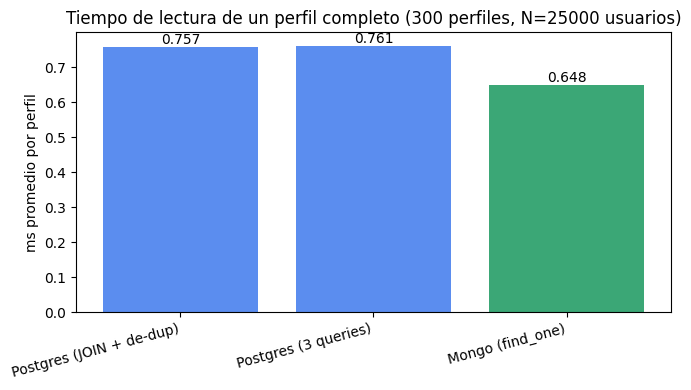

In [ ]:
plt.figure(figsize=(7,4))
nombres = list(resultados.keys())
promedios = [resultados[n][1] for n in nombres]
plt.bar(nombres, promedios, color=["#5b8def", "#5b8def", "#3ba776"])
plt.ylabel("ms promedio por perfil")
plt.title(f"Tiempo de lectura de un perfil completo ({N_REPS} perfiles, N={N_USERS} usuarios)")
plt.xticks(rotation=15, ha="right")
for i, v in enumerate(promedios):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Para discutir en clase:** la diferencia en milisegundos por perfil puede parecer
chica corriendo todo local (sin latencia de red real). Lo importante para señalarles a
los alumnos son los **factores que no cambian con el hardware**:

- **Cantidad de round-trips**: 1 vs 3. En producción, con la base de datos en otro
  servidor, cada round-trip sumaría varios milisegundos reales de latencia de red.
- **Filas devueltas**: el JOIN devuelve `experiencias × educaciones` filas con los
  datos del usuario repetidos; eso es texto de más viajando por la red y más trabajo
  de deserialización.
- **Trabajo en el backend**: Postgres+JOIN necesita el código de `armar_perfil_desde_filas`;
  Mongo no necesita nada, el documento ya es el JSON de respuesta.


### Benchmark B: un endpoint de "listado" (muchos perfiles a la vez)


In [ ]:
N_LISTADO = 500
ids_listado = list(range(1, N_LISTADO + 1))

t0 = time.perf_counter()
placeholders = ",".join(["%s"] * len(ids_listado))
cur.execute(f'''
    SELECT u.id_usuario, u.nombre, u.apellido, u.bio,
           e.empresa, e.cargo, e.anio_inicio, e.anio_fin,
           ed.institucion, ed.titulo
    FROM usuarios u
    LEFT JOIN experiencia e  ON e.id_usuario = u.id_usuario
    LEFT JOIN educacion  ed ON ed.id_usuario = u.id_usuario
    WHERE u.id_usuario IN ({placeholders})
''', ids_listado)
filas = cur.fetchall()
por_usuario = {}
for f in filas:
    por_usuario.setdefault(f[0], []).append(f)
perfiles_pg = [armar_perfil_desde_filas(fs, cols) for fs in por_usuario.values()]
t_pg_listado = time.perf_counter() - t0

t0 = time.perf_counter()
perfiles_mongo = list(col.find({"_id": {"$in": ids_listado}}))
t_mongo_listado = time.perf_counter() - t0

print(f"Postgres (1 query + {len(filas)} filas + reshape en Python): {t_pg_listado:.4f}s")
print(f"Mongo    (1 query, ya viene anidado):                        {t_mongo_listado:.4f}s")


Postgres (1 query + 2926 filas + reshape en Python): 0.0552s
Mongo    (1 query, ya viene anidado):                        0.0162s


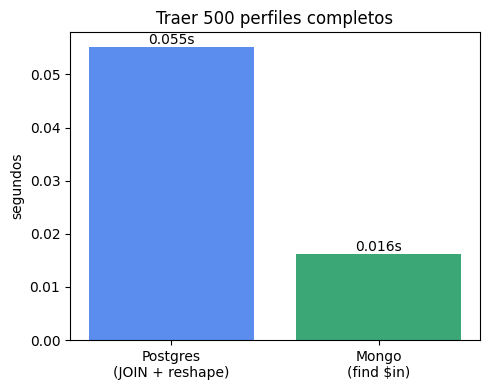

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(["Postgres\n(JOIN + reshape)", "Mongo\n(find $in)"],
        [t_pg_listado, t_mongo_listado], color=["#5b8def", "#3ba776"])
plt.ylabel("segundos")
plt.title(f"Traer {N_LISTADO} perfiles completos")
for i, v in enumerate([t_pg_listado, t_mongo_listado]):
    plt.text(i, v, f"{v:.3f}s", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## Parte 4 — El otro lado de la moneda: cuándo gana lo normalizado

Denormalizar no es gratis: **duplica información** y hace más caro
resolver preguntas que cruzan muchos documentos. Un ejemplo típico: *"¿cuáles son las
5 empresas con más experiencias laborales cargadas?"*. Es una agregación sobre el
array embebido, y en Mongo requiere "desarmar" el array (`$unwind`) antes de agrupar.
En Postgres, `experiencia` ya es una tabla plana: `GROUP BY` directo, con índice.


In [ ]:
# Postgres: GROUP BY directo sobre la tabla plana
t0 = time.perf_counter()
cur.execute('''
    SELECT empresa, COUNT(*) AS total
    FROM experiencia
    GROUP BY empresa
    ORDER BY total DESC
    LIMIT 5
''')
top_pg = cur.fetchall()
t_pg_agg = time.perf_counter() - t0
print(f"Postgres GROUP BY: {t_pg_agg:.4f}s -> {top_pg}")


Postgres GROUP BY: 0.0449s -> [('Gonzalez PLC', 214), ('Gonzalez LLC', 208), ('Gonzalez and Sons', 200), ('Gonzalez Group', 198), ('Gonzalez Ltd', 187)]


In [ ]:
# Mongo: hay que desarmar el array embebido antes de poder agrupar
t0 = time.perf_counter()
pipeline = [
    {"$unwind": "$experiencia"},
    {"$group": {"_id": "$experiencia.empresa", "total": {"$sum": 1}}},
    {"$sort": {"total": -1}},
    {"$limit": 5},
]
top_mongo = list(col.aggregate(pipeline))
t_mongo_agg = time.perf_counter() - t0
print(f"Mongo $unwind + $group: {t_mongo_agg:.4f}s -> {top_mongo}")


Mongo $unwind + $group: 0.1551s -> [{'_id': 'Gonzalez PLC', 'total': 214}, {'_id': 'Gonzalez LLC', 'total': 208}, {'_id': 'Gonzalez and Sons', 'total': 200}, {'_id': 'Gonzalez Group', 'total': 198}, {'_id': 'Gonzalez Ltd', 'total': 187}]


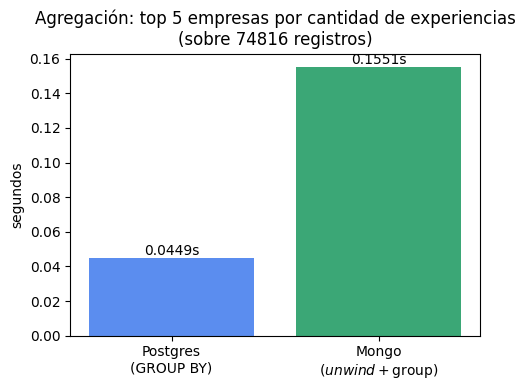

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(["Postgres\n(GROUP BY)", "Mongo\n($unwind + $group)"],
        [t_pg_agg, t_mongo_agg], color=["#5b8def", "#3ba776"])
plt.ylabel("segundos")
plt.title(f"Agregación: top 5 empresas por cantidad de experiencias\n(sobre {len(experiencias)} registros)")
for i, v in enumerate([t_pg_agg, t_mongo_agg]):
    plt.text(i, v, f"{v:.4f}s", ha="center", va="bottom")
plt.tight_layout()
plt.show()


No existe "el modelo ganador" en abstracto. La
pregunta correcta no es *¿SQL o NoSQL?* sino ***¿cuál es el patrón de acceso
dominante de mi aplicación?***

| Patrón de acceso | Gana |
|---|---|
| Leer una entidad completa por su clave (perfil, pedido, producto) | Denormalizado (Mongo) |
| Cruzar/agrupar/filtrar sobre las sub-entidades a través de muchos documentos | Normalizado (SQL) |
| Actualizar un dato que está duplicado en miles de documentos (ej. corregir el nombre de una empresa) | Normalizado (SQL, 1 UPDATE) — en Mongo hay que actualizar N documentos |
| Garantías fuertes de integridad referencial y consistencia transaccional entre entidades | Normalizado (SQL) |

**Preguntas para el debate final:**

1. Si mañana una empresa cambia de nombre, ¿qué hay que hacer en
   cada modelo? ¿Cuántos documentos/filas hay que tocar?
2. ¿Qué pasa con el tamaño en disco?
3. ¿Se podría tener "lo mejor de los dos mundos"? (spoiler: sí — normalizar lo que se
   actualiza mucho y se lee poco, embeber lo que se lee mucho junto y se actualiza poco;
   o usar un modelo híbrido de referencia + cache denormalizado).
